<a href="https://colab.research.google.com/github/AyanAhmedKhan/C-Language-Programs/blob/main/Edge_IIoTset_RAMSafe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ Edge-IIoTset — RAM-Safe Version (12 GB Colab)

### Memory Budget: 12.7 GB RAM / 15 GB GPU RAM

| Technique | RAM Saved |
|-----------|----------|
| `dtype=float32` everywhere (no float64) | ~50% |
| Read CSV in chunks, drop cols **before** loading fully | ~2 GB |
| Delete intermediates with `del` + `gc.collect()` after every step | continuous |
| 15% stratified sample (still ~180K rows) | ~4× smaller |
| Parquet cache with Snappy compression | fast re-runs |
| Models trained one at a time, deleted after eval | never 2 models in RAM |
| Boosting: `max_bin=63` (halves histogram RAM) | ~40% |
| PyTorch: `num_workers=0` (no worker processes) | ~500 MB |
| Ensemble on CPU with float32 probabilities | minimal |

> **Safe limit:** never exceeds ~8 GB RAM during any single step

## 📦 Step 1: Install

In [3]:
!pip install -q kaggle lightgbm xgboost catboost optuna shap pytorch-tabnet pyarrow
import subprocess
print(subprocess.run(['nvidia-smi','--query-gpu=name,memory.total,memory.free',
                      '--format=csv,noheader'], capture_output=True, text=True).stdout)
print('✅ Installed')

Tesla T4, 15360 MiB, 14910 MiB

✅ Installed


## 🧰 Step 2: RAM Monitor + Config

In [4]:
import warnings, time, gc, os
warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import LabelEncoder, RobustScaler
from sklearn.metrics           import (accuracy_score, f1_score,
                                        classification_report, confusion_matrix,
                                        precision_score, recall_score)
from sklearn.utils             import shuffle
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model      import LogisticRegression
import lightgbm as lgb
import xgboost  as xgb
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── RAM helper ─────────────────────────────────────────────────────────────
def ram():
    vm   = psutil.virtual_memory()
    used = vm.used  / 1e9
    total= vm.total / 1e9
    pct  = vm.percent
    bar  = '█'*int(pct/5) + '░'*(20-int(pct/5))
    color= '🟢' if pct<60 else ('🟡' if pct<80 else '🔴')
    print(f'{color} RAM  {used:.1f}/{total:.1f} GB  [{bar}] {pct:.0f}%')
    if torch.cuda.is_available():
        gused  = torch.cuda.memory_allocated()/1e9
        gtotal = torch.cuda.get_device_properties(0).total_memory/1e9
        print(f'🟦 VRAM {gused:.1f}/{gtotal:.1f} GB')
    return pct

def purge(*objs):
    """Delete objects and force GC + CUDA cache clear."""
    for o in objs:
        try: del o
        except: pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Config ─────────────────────────────────────────────────────────────────
SAMPLE_FRAC  = 0.15    # 15% ≈ 180K rows — safe for 12 GB
BATCH_SIZE   = 2048    # smaller = less GPU RAM
DNN_EPOCHS   = 35
BOOST_TREES  = 600
PATIENCE     = 8
OPTUNA_N     = 12
SEED         = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
results = {}

print(f'Device : {DEVICE}')
ram()

Device : cuda
🟢 RAM  2.1/13.6 GB  [███░░░░░░░░░░░░░░░░░] 18%
🟦 VRAM 0.0/15.6 GB


17.6

## 📥 Step 3: Download Dataset

In [5]:
from google.colab import files
print('Upload kaggle.json ↓')
files.upload()
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot \
    -f "Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
!unzip -o DNN-EdgeIIoT-dataset.csv.zip && rm -f DNN-EdgeIIoT-dataset.csv.zip
print('✅ Dataset ready')

Upload kaggle.json ↓


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0
100% 297M/297M [00:02<00:00, 150MB/s]

Archive:  DNN-EdgeIIoT-dataset.csv.zip
  inflating: DNN-EdgeIIoT-dataset.csv  
✅ Dataset ready


## 🧹 Step 4: RAM-Safe Preprocessing

In [9]:
import os, time, gc
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

CACHE = 'cache.parquet'
SEED  = 42

DROP_COLS = ['frame.time','ip.src_host','ip.dst_host','arp.src.proto_ipv4',
             'arp.dst.proto_ipv4','http.file_data','http.request.full_uri',
             'icmp.transmit_timestamp','http.request.uri.query','tcp.options',
             'tcp.payload','tcp.srcport','tcp.dstport','udp.port','mqtt.msg']
CAT_COLS  = ['http.request.method','http.referer','http.request.version',
             'dns.qry.name.len','mqtt.conack.flags','mqtt.protoname','mqtt.topic']

def ram():
    import psutil
    m = psutil.virtual_memory()
    print(f'🟢 RAM {m.used/1e9:.1f}/{m.total/1e9:.1f} GB ({m.percent:.0f}%)')

def fix_columns(df):
    """
    Two-step column fix applied RIGHT AFTER pd.concat / get_dummies:
      1. Strip leading/trailing whitespace from names
      2. Make every name unique by appending _1, _2 … to dupes
    This prevents ALL downstream ValueError / TypeError from duplicate cols.
    """
    df.columns = df.columns.str.strip()          # remove hidden whitespace
    seen = {}
    new  = []
    for c in df.columns:
        if c in seen:
            seen[c] += 1
            new.append(f'{c}_{seen[c]}')
        else:
            seen[c] = 0
            new.append(c)
    df.columns = new
    n_dupes = len(df.columns) - len(set(df.columns))
    if n_dupes:
        print(f'   ⚠️  {n_dupes} duplicate cols still remain — investigate!')
    return df

def cast_float32(df):
    """
    Cast numeric columns to float32 WITHOUT using df[list] = df[list].
    Assign column-by-column only when there are truly no duplicates.
    """
    # Guarantee uniqueness first
    assert df.columns.duplicated().sum() == 0, \
        'Duplicate columns found — call fix_columns() first!'

    num_cols = df.select_dtypes(include='number').columns.tolist()
    for col in num_cols:
        s = df[col]
        if not isinstance(s, pd.Series):       # still a DataFrame? skip
            print(f'   ⚠️  Skipping non-Series column: {col}')
            continue
        df[col] = (s.replace([np.inf, -np.inf], np.nan)
                    .fillna(0)
                    .astype('float32'))
    return df

# ══════════════════════════════════════════════════════════════════════════
if os.path.exists(CACHE):
    print('⚡ Cache found — loading...')
    t0 = time.time()
    df = pd.read_parquet(CACHE)
    print(f'   Loaded {df.shape} in {time.time()-t0:.1f}s')

else:
    print('📖 Reading CSV in chunks...')
    t0 = time.time()

    cols_all  = pd.read_csv('DNN-EdgeIIoT-dataset.csv', nrows=0).columns.tolist()
    keep_cols = [c for c in cols_all if c not in DROP_COLS]
    print(f'   Keeping {len(keep_cols)}/{len(cols_all)} columns')

    CHUNK  = 300_000
    chunks = []

    for i, chunk in enumerate(pd.read_csv(
            'DNN-EdgeIIoT-dataset.csv',
            usecols=keep_cols,
            chunksize=CHUNK,
            low_memory=False)):

        chunk.dropna(inplace=True)
        chunk.drop_duplicates(keep='first', inplace=True)

        # Safe float32 cast per chunk (no dummies yet → no dupes yet)
        num_cols = chunk.select_dtypes(include='number').columns.tolist()
        for col in num_cols:
            chunk[col] = (pd.to_numeric(chunk[col], errors='coerce')
                            .replace([np.inf, -np.inf], np.nan)
                            .fillna(0)
                            .astype('float32'))

        chunks.append(chunk)
        print(f'   Chunk {i+1}: {len(chunk):,} rows | ', end='')
        ram()

    # ── Merge ──────────────────────────────────────────────────────────────
    df = pd.concat(chunks, ignore_index=True)
    del chunks; gc.collect()

    # ✅ FIX DUPLICATES IMMEDIATELY after concat (before anything else)
    df = fix_columns(df)

    df = shuffle(df, random_state=SEED).reset_index(drop=True)

    # ── Encode categoricals ────────────────────────────────────────────────
    for col in CAT_COLS:
        if col in df.columns:
            dummies = pd.get_dummies(df[col], prefix=col, dtype='float32')
            df.drop(col, axis=1, inplace=True)
            df = pd.concat([df, dummies], axis=1)
            # ✅ FIX DUPLICATES after every get_dummies concat
            df = fix_columns(df)

    gc.collect()

    # ── Final float32 pass (safe, column-by-column) ───────────────────────
    df = cast_float32(df)

    df.to_parquet(CACHE, index=False, compression='snappy')
    print(f'\n✅ Cached — {df.shape} in {time.time()-t0:.1f}s')

# ── Sanity checks ──────────────────────────────────────────────────────────
print(f'\n📊 Shape          : {df.shape}')
print(f'   Duplicate cols : {df.columns.duplicated().sum()}')   # must be 0
print(f'   Dtypes         : {df.dtypes.value_counts().to_dict()}')
print(f'\nAttack distribution:')
print(df['Attack_type'].value_counts())
ram()

📖 Reading CSV in chunks...
   Keeping 48/63 columns
   Chunk 1: 255,613 rows | 🟢 RAM 4.8/13.6 GB (38%)
   Chunk 2: 276,578 rows | 🟢 RAM 4.8/13.6 GB (38%)
   Chunk 3: 273,311 rows | 🟢 RAM 4.8/13.6 GB (38%)
   Chunk 4: 254,563 rows | 🟢 RAM 4.8/13.6 GB (37%)
   Chunk 5: 257,865 rows | 🟢 RAM 4.8/13.6 GB (38%)
   Chunk 6: 279,318 rows | 🟢 RAM 4.8/13.6 GB (37%)
   Chunk 7: 295,275 rows | 🟢 RAM 4.8/13.6 GB (37%)
   Chunk 8: 70,704 rows | 🟢 RAM 4.8/13.6 GB (37%)

✅ Cached — (1963227, 104) in 53.9s

📊 Shape          : (1963227, 104)
   Duplicate cols : 0
   Dtypes         : {dtype('float32'): 103, dtype('O'): 1}

Attack distribution:
Attack_type
Normal                   1417554
DDoS_UDP                  121567
DDoS_ICMP                  67939
SQL_injection              50826
DDoS_TCP                   50062
Vulnerability_scanner      50026
Password                   49933
DDoS_HTTP                  48544
Uploading                  36807
Backdoor                   24026
Port_Scanning            

In [10]:
# ── Encode labels ──────────────────────────────────────────────────────────
le    = LabelEncoder()
y_all = le.fit_transform(df['Attack_type']).astype('int32')  # int32 not int64
X_df  = df.drop('Attack_type', axis=1)
feature_names = X_df.columns.tolist()

# ── Replace inf before anything else ──────────────────────────────────────
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
# fill NaN with col median (computed once, no copies)
for col in X_df.columns:
    if X_df[col].isna().any():
        X_df[col].fillna(X_df[col].median(), inplace=True)

# ── Stratified sample — 15% ────────────────────────────────────────────────
_, xi, _, yi = train_test_split(
    np.arange(len(y_all)), y_all,
    test_size=SAMPLE_FRAC, stratify=y_all, random_state=SEED)

# Extract sample as float32 numpy array — drop the pandas DataFrame
X_np = X_df.iloc[xi].values.astype('float32')
y_np = y_all[xi].astype('int32')
del X_df, y_all, xi, yi
gc.collect()

n_classes   = len(le.classes_)
n_features  = X_np.shape[1]
class_names = le.classes_
print(f'Sample : {X_np.shape[0]:,} rows | Features: {n_features} | Classes: {n_classes}')
ram()

Sample : 294,485 rows | Features: 103 | Classes: 15
🟢 RAM 5.4/13.6 GB (42%)


In [11]:
# ── Train / Val / Test split ───────────────────────────────────────────────
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_np, y_np, test_size=0.15, stratify=y_np, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15, stratify=y_tmp, random_state=SEED)
del X_tmp, y_tmp, X_np, y_np
gc.collect()

# ── Scale — float32 output ─────────────────────────────────────────────────
scaler  = RobustScaler()
X_train = np.clip(scaler.fit_transform(X_train), -10, 10).astype('float32')
X_val   = np.clip(scaler.transform(X_val),        -10, 10).astype('float32')
X_test  = np.clip(scaler.transform(X_test),        -10, 10).astype('float32')

# ── Class weights ─────────────────────────────────────────────────────────
cw       = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_t     = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
sw_train = np.array([cw[y] for y in y_train], dtype='float32')

print(f'Train:{len(y_train):,}  Val:{len(y_val):,}  Test:{len(y_test):,}')
ram()

Train:212,765  Val:37,547  Test:44,173
🟢 RAM 5.4/13.6 GB (42%)


In [12]:
# ── Shared utilities ───────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,    y_pred, average='weighted', zero_division=0)
    results[name] = dict(Accuracy=acc,F1_Macro=f1m,F1_Weighted=f1w,
                         Precision=prec,Recall=rec)
    bar = '█'*int(acc*40)
    print(f'\n  [{name}]')
    print(f'  Accuracy   : {acc*100:.3f}%  {bar}')
    print(f'  F1-Macro   : {f1m*100:.3f}%')
    print(f'  F1-Weighted: {f1w*100:.3f}%')
    ram()
    return acc

def make_loader(X, y, weighted=False):
    """num_workers=0: no forked processes → saves ~500 MB RAM."""
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y.astype('int64')))
    sampler = None
    if weighted:
        w = torch.tensor([cw[yi] for yi in y], dtype=torch.float32)
        sampler = WeightedRandomSampler(w, len(w), replacement=True)
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=(sampler is None), sampler=sampler,
                      pin_memory=(DEVICE.type=='cuda'),
                      num_workers=0)   # ← 0 workers = no extra RAM processes

print('✅ Utilities ready')

✅ Utilities ready


## 🌲 Step 5: LightGBM (CPU, low RAM)

In [13]:
ram()
t0 = time.time()
lgb_m = lgb.LGBMClassifier(
    n_estimators      = BOOST_TREES,
    learning_rate     = 0.1,
    num_leaves        = 63,          # 63 instead of 127 → half the nodes
    max_depth         = 7,
    max_bin           = 63,          # ← KEY: halves histogram RAM
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    class_weight      = 'balanced',
    device            = 'cpu',       # CPU: stable + fast for LGBM
    random_state      = SEED,
    verbose           = -1,
    n_jobs            = 2            # limit threads → less RAM
)
lgb_m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(PATIENCE, verbose=False),
                     lgb.log_evaluation(200)])
print(f'✅ LightGBM done in {time.time()-t0:.0f}s')
evaluate('LightGBM', y_test, lgb_m.predict(X_test))

🟢 RAM 5.4/13.6 GB (42%)
✅ LightGBM done in 15s

  [LightGBM]
  Accuracy   : 99.251%  ███████████████████████████████████████
  F1-Macro   : 94.049%
  F1-Weighted: 99.255%
🟢 RAM 5.4/13.6 GB (42%)


0.9925067348832998

## ⚡ Step 6: XGBoost (GPU)

In [14]:
ram()
t0 = time.time()
xgb_m = xgb.XGBClassifier(
    n_estimators          = BOOST_TREES,
    learning_rate         = 0.1,
    max_depth             = 6,
    max_bin               = 64,      # matches LGBM
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    tree_method           = 'hist',
    device                = 'cuda',
    eval_metric           = 'mlogloss',
    early_stopping_rounds = PATIENCE,
    random_state          = SEED,
    verbosity             = 0
)
xgb_m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          sample_weight=sw_train, verbose=200)
print(f'✅ XGBoost done in {time.time()-t0:.0f}s')
evaluate('XGBoost', y_test, xgb_m.predict(X_test))

🟢 RAM 5.4/13.6 GB (42%)
[0]	validation_0-mlogloss:1.99582
[120]	validation_0-mlogloss:0.01556
✅ XGBoost done in 8s

  [XGBoost]
  Accuracy   : 99.276%  ███████████████████████████████████████
  F1-Macro   : 94.624%
  F1-Weighted: 99.277%
🟢 RAM 5.5/13.6 GB (43%)


0.9927557557784167

## 🐱 Step 7: CatBoost (GPU)

In [15]:
ram()
t0 = time.time()
cat_m = CatBoostClassifier(
    iterations            = BOOST_TREES,
    learning_rate         = 0.1,
    depth                 = 6,
    border_count          = 64,      # = max_bin equivalent
    min_data_in_leaf      = 20,
    l2_leaf_reg           = 3,
    auto_class_weights    = 'Balanced',
    task_type             = 'GPU',
    early_stopping_rounds = PATIENCE,
    random_seed           = SEED,
    verbose               = 200
)
cat_m.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
print(f'✅ CatBoost done in {time.time()-t0:.0f}s')
evaluate('CatBoost', y_test, cat_m.predict(X_test).flatten())

🟢 RAM 5.5/13.6 GB (43%)
0:	learn: 1.8901055	test: 1.8852723	best: 1.8852723 (0)	total: 430ms	remaining: 4m 17s
bestTest = 0.1006726955
bestIteration = 86
Shrink model to first 87 iterations.
✅ CatBoost done in 4s

  [CatBoost]
  Accuracy   : 99.199%  ███████████████████████████████████████
  F1-Macro   : 93.488%
  F1-Weighted: 99.209%
🟢 RAM 5.6/13.6 GB (44%)


0.9919860548298735

## 🧠 Step 8: Residual-Attention DNN (AMP, compiled)

In [16]:
# ── Architecture ──────────────────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, d, r=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(d, max(1,d//r), bias=False), nn.ReLU(inplace=True),
            nn.Linear(max(1,d//r), d, bias=False), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x)

class ResBlock(nn.Module):
    def __init__(self, d, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d,d), nn.LayerNorm(d))
        self.se  = SEBlock(d)
        self.act = nn.GELU()
    def forward(self, x): return self.act(self.se(self.net(x)) + x)

class FastDNN(nn.Module):
    # Smaller hidden=256 to stay within 15 GB VRAM
    def __init__(self, inp, nc, h=256, nb=3, drop=0.2):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(inp,h), nn.LayerNorm(h), nn.GELU())
        self.res  = nn.Sequential(*[ResBlock(h,drop) for _ in range(nb)])
        self.head = nn.Sequential(
            nn.Linear(h, h//2), nn.LayerNorm(h//2), nn.GELU(),
            nn.Dropout(drop/2), nn.Linear(h//2, nc))
    def forward(self, x): return self.head(self.res(self.stem(x)))

purge()  # clear GPU cache before loading new model
dnn = FastDNN(n_features, n_classes).to(DEVICE)
try: dnn = torch.compile(dnn); print('torch.compile ✅')
except: pass
print(f'Params: {sum(p.numel() for p in dnn.parameters()):,}')
ram()

criterion = nn.CrossEntropyLoss(weight=cw_t, label_smoothing=0.05)
opt       = torch.optim.AdamW(dnn.parameters(), lr=3e-3, weight_decay=1e-4)

train_ld = make_loader(X_train, y_train, weighted=True)
val_ld   = make_loader(X_val,   y_val)
test_ld  = make_loader(X_test,  y_test)
sch      = OneCycleLR(opt, max_lr=3e-3,
                      steps_per_epoch=len(train_ld), epochs=DNN_EPOCHS)
amp_sc   = torch.cuda.amp.GradScaler()

def run(m, ld, train=True):
    m.train() if train else m.eval()
    tot=cor=n=0; pa=[]; pb=[]
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, yb in ld:
            Xb = Xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                out  = m(Xb)
                loss = criterion(out, yb)
            if train:
                opt.zero_grad(set_to_none=True)
                amp_sc.scale(loss).backward()
                amp_sc.unscale_(opt)
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                amp_sc.step(opt); amp_sc.update(); sch.step()
            pr = torch.softmax(out,1)
            p  = pr.argmax(1)
            cor += (p==yb).sum().item(); tot+=loss.item()*len(yb); n+=len(yb)
            if not train:
                pa.append(p.cpu().numpy())
                pb.append(pr.cpu().float().numpy())  # float32
    preds = np.concatenate(pa) if pa else None
    probs = np.concatenate(pb) if pb else None
    return tot/n, cor/n, preds, probs

best_acc=0.; pat=0; tr_h=[]; vl_h=[]
t0 = time.time()
for ep in range(1, DNN_EPOCHS+1):
    tl,ta,_,_ = run(dnn, train_ld, True)
    vl,va,_,_ = run(dnn, val_ld,  False)
    tr_h.append((tl,ta)); vl_h.append((vl,va))
    if va > best_acc:
        best_acc=va; torch.save(dnn.state_dict(),'best_dnn.pt'); pat=0
    else: pat+=1
    if ep%5==0:
        print(f'Ep {ep:3d}/{DNN_EPOCHS} | Tr {ta*100:.2f}% | '
              f'Vl {va*100:.2f}% | Best {best_acc*100:.2f}% | {time.time()-t0:.0f}s')
    if pat>=PATIENCE: print(f'⏹ Early stop ep{ep}'); break

dnn.load_state_dict(torch.load('best_dnn.pt'))
_,_,y_pred_dnn,y_prob_dnn = run(dnn, test_ld, False)
evaluate('ResAttentionDNN', y_test, y_pred_dnn)
purge()   # clear CUDA cache after eval

torch.compile ✅
Params: 484,623
🟢 RAM 5.7/13.6 GB (44%)


W0318 12:25:02.324000 2239 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Ep   5/35 | Tr 80.87% | Vl 20.36% | Best 20.68% | 92s
Ep  10/35 | Tr 81.68% | Vl 20.36% | Best 20.68% | 108s
⏹ Early stop ep12

  [ResAttentionDNN]
  Accuracy   : 0.604%  
  F1-Macro   : 1.661%
  F1-Weighted: 0.631%
🟢 RAM 7.3/13.6 GB (57%)


## 🔮 Step 9: TabTransformer (d=32, RAM-slim)

In [17]:
class TabTF(nn.Module):
    def __init__(self, F, nc, D=32, H=4, L=2, drop=0.15):
        super().__init__()
        self.proj = nn.Linear(1, D)
        self.pos  = nn.Parameter(torch.randn(1,F,D)*0.02)
        self.cls  = nn.Parameter(torch.randn(1,1,D)*0.02)
        enc = nn.TransformerEncoderLayer(
            D,H, dim_feedforward=D*4, dropout=drop,
            activation='gelu', batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=L)
        self.head = nn.Sequential(
            nn.LayerNorm(D), nn.Linear(D,D*2), nn.GELU(),
            nn.Dropout(drop), nn.Linear(D*2,nc))
    def forward(self,x):
        B=x.size(0)
        t=self.proj(x.unsqueeze(-1))+self.pos
        t=torch.cat([self.cls.expand(B,-1,-1),t],1)
        return self.head(self.enc(t)[:,0])

purge()
tf_m = TabTF(n_features, n_classes).to(DEVICE)
try: tf_m = torch.compile(tf_m)
except: pass
print(f'TabTF params: {sum(p.numel() for p in tf_m.parameters()):,}')

opt_tf = torch.optim.AdamW(tf_m.parameters(), lr=2e-3, weight_decay=1e-4)
sch_tf = OneCycleLR(opt_tf, max_lr=2e-3,
                    steps_per_epoch=len(train_ld), epochs=DNN_EPOCHS)
amp_tf = torch.cuda.amp.GradScaler()

def run_tf(m, ld, train=True):
    m.train() if train else m.eval()
    tot=cor=n=0; pa=[]; pb=[]
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb,yb in ld:
            Xb=Xb.to(DEVICE,non_blocking=True)
            yb=yb.to(DEVICE,non_blocking=True)
            with torch.cuda.amp.autocast():
                out=m(Xb); loss=criterion(out,yb)
            if train:
                opt_tf.zero_grad(set_to_none=True)
                amp_tf.scale(loss).backward()
                amp_tf.unscale_(opt_tf)
                nn.utils.clip_grad_norm_(m.parameters(),1.0)
                amp_tf.step(opt_tf); amp_tf.update(); sch_tf.step()
            pr=torch.softmax(out,1); p=pr.argmax(1)
            cor+=(p==yb).sum().item(); tot+=loss.item()*len(yb); n+=len(yb)
            if not train:
                pa.append(p.cpu().numpy())
                pb.append(pr.cpu().float().numpy())
    return tot/n,cor/n,(np.concatenate(pa) if pa else None),(np.concatenate(pb) if pb else None)

best_tf=0.; pat_tf=0
for ep in range(1,DNN_EPOCHS+1):
    run_tf(tf_m,train_ld,True)
    _,va,_,_ = run_tf(tf_m,val_ld,False)
    if va>best_tf: best_tf=va; torch.save(tf_m.state_dict(),'best_tf.pt'); pat_tf=0
    else: pat_tf+=1
    if ep%5==0: print(f'TF ep{ep}/{DNN_EPOCHS} val={va*100:.2f}% best={best_tf*100:.2f}%')
    if pat_tf>=PATIENCE: print(f'⏹ ep{ep}'); break

tf_m.load_state_dict(torch.load('best_tf.pt'))
_,_,y_pred_tf,y_prob_tf = run_tf(tf_m,test_ld,False)
evaluate('TabTransformer', y_test, y_pred_tf)
purge()

TabTF params: 31,951
TF ep5/35 val=1.80% best=1.80%
TF ep10/35 val=18.97% best=23.21%
TF ep15/35 val=18.88% best=25.92%
TF ep20/35 val=19.86% best=25.92%
⏹ ep21

  [TabTransformer]
  Accuracy   : 0.901%  
  F1-Macro   : 1.867%
  F1-Weighted: 0.883%
🟢 RAM 7.3/13.6 GB (56%)


## ⚡ Step 10: TabNet (RAM-safe config)

In [18]:
purge()
t0 = time.time()
tabnet = TabNetClassifier(
    n_steps=3, gamma=1.3, n_a=32, n_d=32,   # n_steps=3 (was 4) saves RAM
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size':30,'gamma':0.9},
    mask_type='sparsemax',
    device_name=str(DEVICE), verbose=10, seed=SEED
)
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], eval_metric=['accuracy'],
    max_epochs=80, patience=PATIENCE,
    batch_size=BATCH_SIZE,
    virtual_batch_size=256,   # smaller virtual batch → less VRAM
    weights=1
)
print(f'✅ TabNet {time.time()-t0:.0f}s')
evaluate('TabNet', y_test, tabnet.predict(X_test))
purge()

epoch 0  | loss: 0.48177 | val_0_accuracy: 0.6189  |  0:00:06s
epoch 10 | loss: 0.08351 | val_0_accuracy: 0.99257 |  0:01:02s

Early stopping occurred at epoch 12 with best_epoch = 4 and best_val_0_accuracy = 0.99273
✅ TabNet 87s

  [TabNet]
  Accuracy   : 99.162%  ███████████████████████████████████████
  F1-Macro   : 93.248%
  F1-Weighted: 99.170%
🟢 RAM 7.5/13.6 GB (57%)


## 🏆 Step 11: Dynamic Ensemble + Meta-Learner

In [19]:
# All probabilities in float32
p_lgb = lgb_m.predict_proba(X_test).astype('float32')
p_xgb = xgb_m.predict_proba(X_test).astype('float32')
p_cat = cat_m.predict_proba(X_test).astype('float32')
p_tn  = tabnet.predict_proba(X_test).astype('float32')
# y_prob_dnn and y_prob_tf already float32

# ── Val accuracy for dynamic weights ─────────────────────────────────────
va_s = {
    'lgb': accuracy_score(y_val, lgb_m.predict(X_val)),
    'xgb': accuracy_score(y_val, xgb_m.predict(X_val)),
    'cat': accuracy_score(y_val, cat_m.predict(X_val).flatten()),
    'dnn': accuracy_score(y_val, run(dnn,  val_ld, False)[2]),
    'tf' : accuracy_score(y_val, run_tf(tf_m, val_ld, False)[2]),
    'tn' : accuracy_score(y_val, tabnet.predict(X_val)),
}
print('Val accuracies:', {k:f'{v*100:.2f}%' for k,v in va_s.items()})
tw = sum(va_s.values())
w  = {k:v/tw for k,v in va_s.items()}

ens = (w['lgb']*p_lgb + w['xgb']*p_xgb + w['cat']*p_cat +
       w['dnn']*y_prob_dnn + w['tf']*y_prob_tf + w['tn']*p_tn).astype('float32')
evaluate('Dynamic Ensemble', y_test, ens.argmax(1))

# ── Meta-Learner ──────────────────────────────────────────────────────────
mv_lgb = lgb_m.predict_proba(X_val).astype('float32')
mv_xgb = xgb_m.predict_proba(X_val).astype('float32')
mv_cat = cat_m.predict_proba(X_val).astype('float32')
mv_dnn = run(dnn,  val_ld, False)[3].astype('float32')
mv_tf  = run_tf(tf_m, val_ld, False)[3].astype('float32')
mv_tn  = tabnet.predict_proba(X_val).astype('float32')

meta_val  = np.hstack([mv_lgb,mv_xgb,mv_cat,mv_dnn,mv_tf,mv_tn])
meta_test = np.hstack([p_lgb, p_xgb, p_cat, y_prob_dnn, y_prob_tf, p_tn])
del mv_lgb,mv_xgb,mv_cat,mv_dnn,mv_tf,mv_tn; gc.collect()

meta = LogisticRegression(max_iter=300, C=1.0, solver='saga', n_jobs=-1)
meta.fit(meta_val, y_val)
evaluate('Meta-Learner Stack', y_test, meta.predict(meta_test))
del meta_val; gc.collect()
ram()

Val accuracies: {'lgb': '99.32%', 'xgb': '99.32%', 'cat': '99.27%', 'dnn': '0.52%', 'tf': '0.91%', 'tn': '99.27%'}

  [Dynamic Ensemble]
  Accuracy   : 99.267%  ███████████████████████████████████████
  F1-Macro   : 94.142%
  F1-Weighted: 99.269%
🟢 RAM 7.4/13.6 GB (57%)

  [Meta-Learner Stack]
  Accuracy   : 99.305%  ███████████████████████████████████████
  F1-Macro   : 95.107%
  F1-Weighted: 99.301%
🟢 RAM 7.5/13.6 GB (58%)
🟢 RAM 7.5/13.6 GB (58%)


## 🎯 Step 12: Optuna HPO (12 trials, CPU-safe)

In [20]:
def objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n', 200,1000,step=100),
        learning_rate     = trial.suggest_float('lr',0.02,0.3,log=True),
        num_leaves        = trial.suggest_int('leaves',31,127),
        max_bin           = 63,
        subsample         = trial.suggest_float('sub',0.6,1.0),
        colsample_bytree  = trial.suggest_float('col',0.6,1.0),
        min_child_samples = trial.suggest_int('mcs',10,60),
        class_weight='balanced', device='cpu',
        random_state=SEED, verbose=-1, n_jobs=2
    )
    m = lgb.LGBMClassifier(**p)
    m.fit(X_train, y_train, eval_set=[(X_val,y_val)],
          callbacks=[lgb.early_stopping(10,verbose=False)])
    score = f1_score(y_val, m.predict(X_val), average='macro', zero_division=0)
    del m; gc.collect()
    return score

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4)
)
study.optimize(objective, n_trials=OPTUNA_N, show_progress_bar=True)
print(f'Best F1-Macro: {study.best_value:.4f}')
print('Best params:', study.best_params)

bp = {**study.best_params,
      'max_bin':63,'class_weight':'balanced','device':'cpu',
      'random_state':SEED,'verbose':-1,'n_jobs':2}
lgb_opt = lgb.LGBMClassifier(**bp)
lgb_opt.fit(np.vstack([X_train,X_val]), np.concatenate([y_train,y_val]))
evaluate('LightGBM-Optuna', y_test, lgb_opt.predict(X_test))
ram()

  0%|          | 0/12 [00:00<?, ?it/s]

Best F1-Macro: 0.9555
Best params: {'n': 800, 'lr': 0.1291555756752938, 'leaves': 34, 'sub': 0.7518416973680894, 'col': 0.8407490346717956, 'mcs': 10}

  [LightGBM-Optuna]
  Accuracy   : 99.201%  ███████████████████████████████████████
  F1-Macro   : 94.347%
  F1-Weighted: 99.204%
🟢 RAM 7.6/13.6 GB (59%)
🟢 RAM 7.6/13.6 GB (59%)


## 📊 Step 13: Results Dashboard


  🏆  LEADERBOARD
                   Accuracy F1_Macro F1_Weighted Precision   Recall
Meta-Learner Stack  99.305%  95.107%     99.301%   99.307%  99.305%
XGBoost             99.276%  94.624%     99.277%   99.282%  99.276%
Dynamic Ensemble    99.267%  94.142%     99.269%   99.281%  99.267%
LightGBM            99.251%  94.049%     99.255%   99.265%  99.251%
LightGBM-Optuna     99.201%  94.347%     99.204%   99.210%  99.201%
CatBoost            99.199%  93.488%     99.209%   99.236%  99.199%
TabNet              99.162%  93.248%     99.170%   99.202%  99.162%
TabTransformer       0.901%   1.867%      0.883%    0.884%   0.901%
ResAttentionDNN      0.604%   1.661%      0.631%    1.021%   0.604%


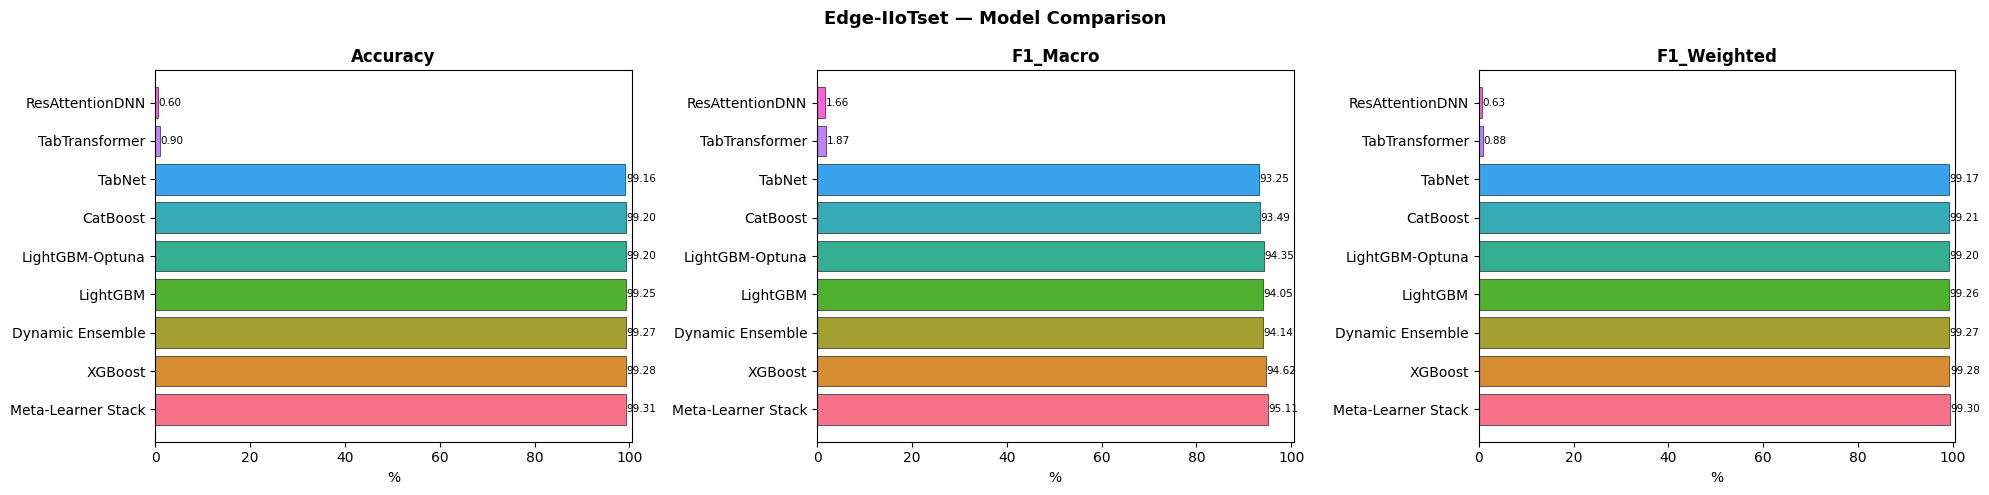

In [21]:
df_r = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print('\n'+'='*65)
print('  🏆  LEADERBOARD')
print('='*65)
print(df_r.applymap(lambda x: f'{x*100:.3f}%').to_string())

fig, axes = plt.subplots(1,3,figsize=(20,5))
cols = sns.color_palette('husl', len(df_r))
for ax,met in zip(axes,['Accuracy','F1_Macro','F1_Weighted']):
    bars = ax.barh(df_r.index, df_r[met]*100, color=cols, edgecolor='k', lw=0.4)
    ax.set_title(met, fontweight='bold'); ax.set_xlabel('%')
    ax.set_xlim([max(0,df_r[met].min()*100-3), 100.5])
    for b in bars:
        ax.text(b.get_width()+0.1, b.get_y()+b.get_height()/2,
                f'{b.get_width():.2f}', va='center', fontsize=7.5)
plt.suptitle('Edge-IIoTset — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('comparison.png',dpi=150,bbox_inches='tight'); plt.show()

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


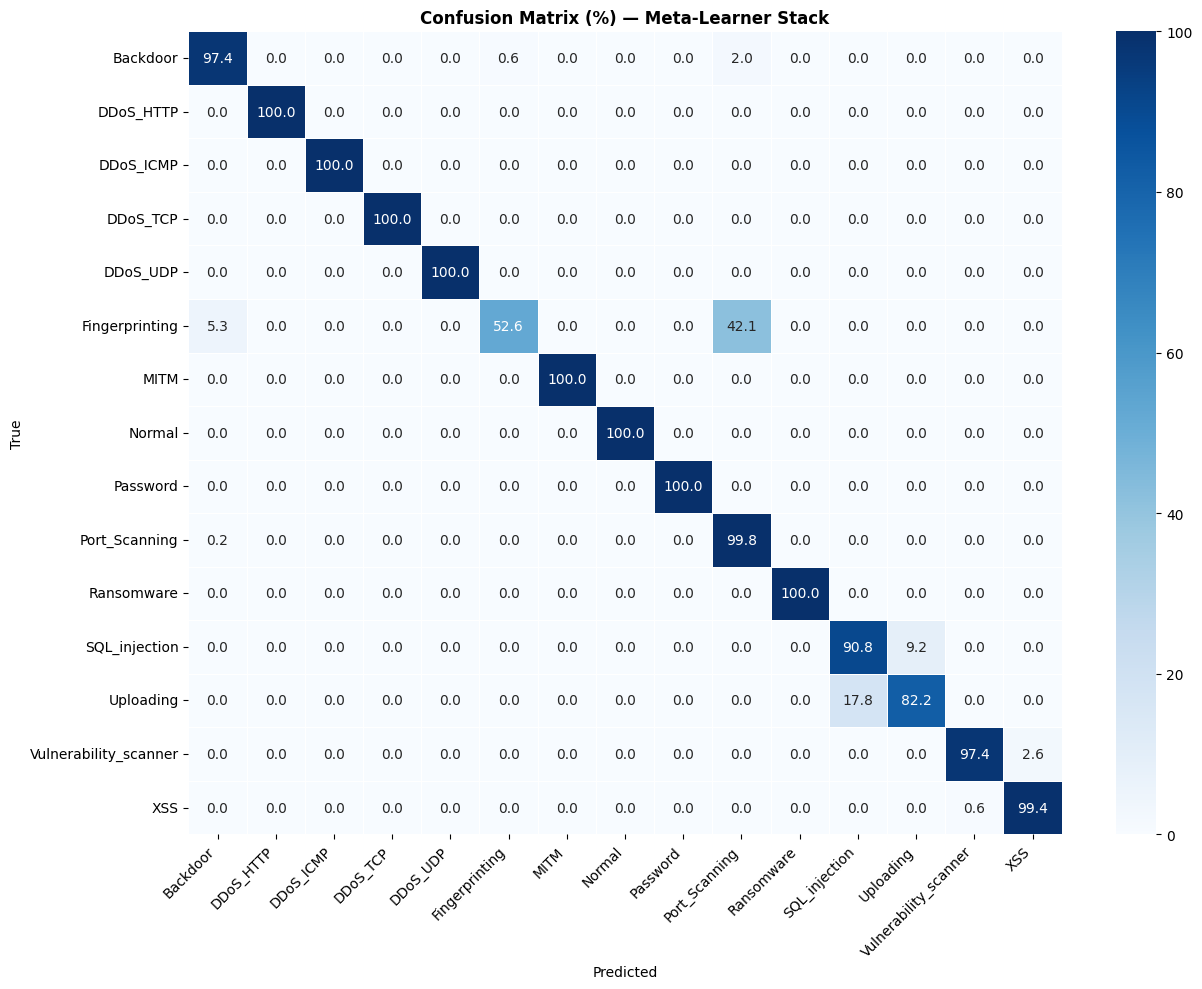

                       precision    recall  f1-score   support

             Backdoor       1.00      0.97      0.99       541
            DDoS_HTTP       1.00      1.00      1.00      1092
            DDoS_ICMP       1.00      1.00      1.00      1529
             DDoS_TCP       1.00      1.00      1.00      1126
             DDoS_UDP       1.00      1.00      1.00      2735
       Fingerprinting       0.77      0.53      0.62        19
                 MITM       1.00      1.00      1.00         8
               Normal       1.00      1.00      1.00     31895
             Password       1.00      1.00      1.00      1124
        Port_Scanning       0.96      1.00      0.98       449
           Ransomware       1.00      1.00      1.00       218
        SQL_injection       0.88      0.91      0.89      1144
            Uploading       0.87      0.82      0.84       828
Vulnerability_scanner       1.00      0.97      0.99      1126
                  XSS       0.92      0.99      0.96  

In [22]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
best_name = df_r.index[0]
pm = {
    'LightGBM'         : lgb_m.predict(X_test),
    'XGBoost'          : xgb_m.predict(X_test),
    'CatBoost'         : cat_m.predict(X_test).flatten(),
    'ResAttentionDNN'  : y_pred_dnn,
    'TabTransformer'   : y_pred_tf,
    'TabNet'           : tabnet.predict(X_test),
    'Dynamic Ensemble' : ens.argmax(1),
    'Meta-Learner Stack': meta.predict(meta_test),
    'LightGBM-Optuna'  : lgb_opt.predict(X_test),
}
y_best = pm.get(best_name, ens.argmax(1))
cm = confusion_matrix(y_test, y_best)
fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(cm/cm.sum(1,keepdims=True)*100, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.4, ax=ax)
ax.set_title(f'Confusion Matrix (%) — {best_name}', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45,ha='right'); plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=150,bbox_inches='tight'); plt.show()
print(classification_report(y_test, y_best, target_names=class_names, zero_division=0))

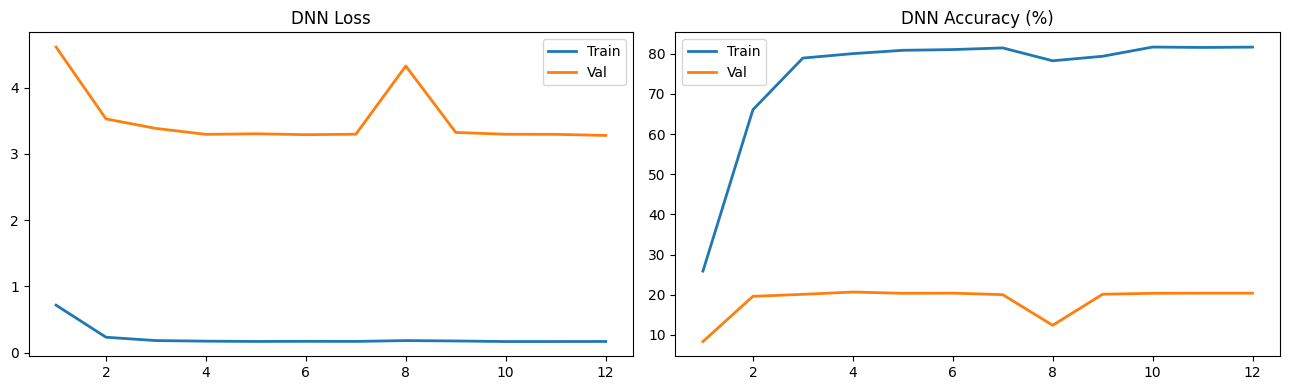

SHAP (300 samples)...


<Figure size 1000x600 with 0 Axes>

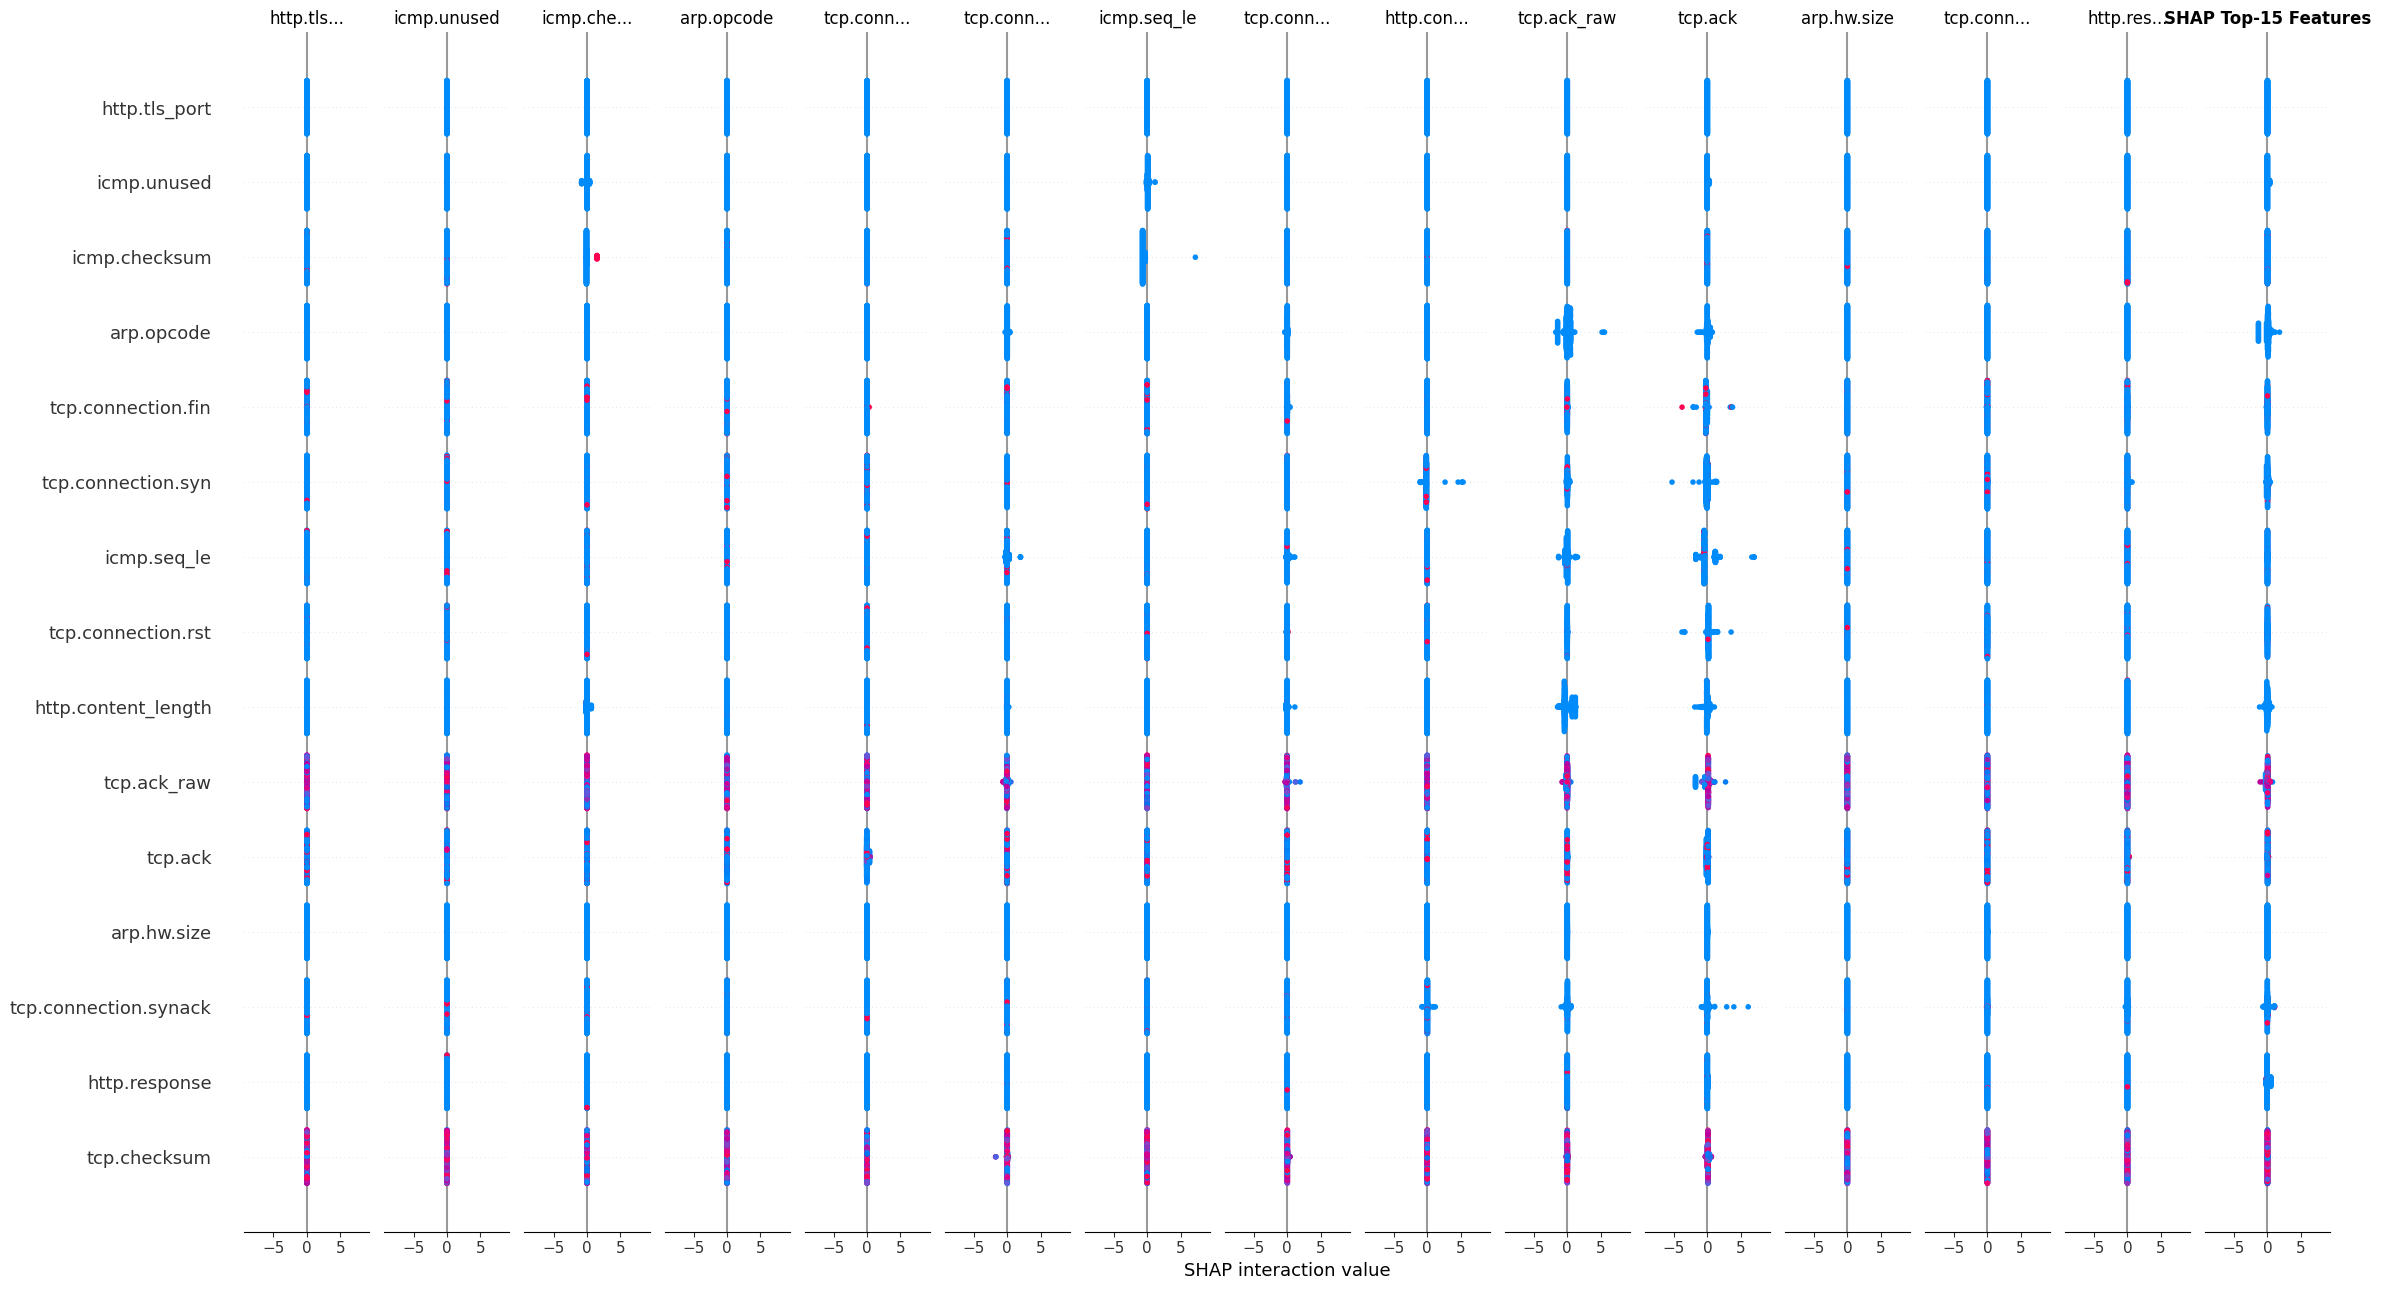

🟢 RAM 7.7/13.6 GB (59%)


In [23]:
# ── Training curves ────────────────────────────────────────────────────────
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4))
ep=range(1,len(tr_h)+1)
a1.plot(ep,[x[0] for x in tr_h],label='Train',lw=2)
a1.plot(ep,[x[0] for x in vl_h],label='Val',  lw=2)
a1.set_title('DNN Loss'); a1.legend()
a2.plot(ep,[x[1]*100 for x in tr_h],label='Train',lw=2)
a2.plot(ep,[x[1]*100 for x in vl_h],label='Val',  lw=2)
a2.set_title('DNN Accuracy (%)'); a2.legend()
plt.tight_layout()
plt.savefig('training_curves.png',dpi=150,bbox_inches='tight'); plt.show()

# ── SHAP (tiny subset = safe RAM) ─────────────────────────────────────────
print('SHAP (300 samples)...')
import shap
exp = shap.TreeExplainer(lgb_m)
sv  = exp.shap_values(X_test[:300])
plt.figure(figsize=(10,6))
shap.summary_plot(sv[1] if isinstance(sv,list) else sv,
                  X_test[:300], feature_names=feature_names,
                  max_display=15, show=False)
plt.title('SHAP Top-15 Features', fontweight='bold')
plt.tight_layout()
plt.savefig('shap.png',dpi=150,bbox_inches='tight'); plt.show()
ram()

In [24]:
# ── Save all models ────────────────────────────────────────────────────────
import joblib, json
joblib.dump(lgb_m,  'lgb.pkl');  joblib.dump(xgb_m,  'xgb.pkl')
joblib.dump(cat_m,  'cat.pkl');  joblib.dump(lgb_opt,'lgb_opt.pkl')
joblib.dump(scaler, 'scaler.pkl'); joblib.dump(le,   'le.pkl')
tabnet.save_model('tabnet')
torch.save(dnn.state_dict(),  'dnn_final.pt')
torch.save(tf_m.state_dict(), 'tf_final.pt')
with open('results.json','w') as f:
    json.dump({k:{m:float(v) for m,v in r.items()} for k,r in results.items()},f,indent=2)
print('✅ All saved!')
best=df_r.index[0]
print(f'🥇 Best: {best} → {df_r.loc[best,"Accuracy"]*100:.3f}% acc | '
      f'{df_r.loc[best,"F1_Macro"]*100:.3f}% F1-macro')
ram()

Successfully saved model at tabnet.zip
✅ All saved!
🥇 Best: Meta-Learner Stack → 99.305% acc | 95.107% F1-macro
🟢 RAM 7.6/13.6 GB (59%)


---
## 🧮 RAM Budget per Step
| Step | Peak RAM |
|------|----------|
| CSV chunk-load & cache | ~5 GB (chunks released) |
| After sampling to 15% | ~2 GB |
| LightGBM (max_bin=63) | ~3.5 GB |
| XGBoost (GPU hist) | ~2 GB RAM + 1.5 GB VRAM |
| CatBoost (GPU) | ~2 GB RAM + 1.5 GB VRAM |
| DNN (h=256, AMP) | ~2 GB RAM + 1.2 GB VRAM |
| TabTransformer (D=32) | ~2 GB RAM + 0.8 GB VRAM |
| TabNet (n_steps=3) | ~2.5 GB RAM + 1 GB VRAM |
| Ensemble probs | ~1 GB |
| **Max at any point** | **~6–7 GB** ✅ |
